<a href="https://colab.research.google.com/github/simsim-px/Praktikum-Fisika/blob/main/UAP_Milikan_Koreksi_Cunnningham.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import linregress
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'serif',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
})

In [29]:
l       = 6.00e-3       # Jarak antar pelat kapasitor (m)
d_grid  = 1.00e-3       # Jarak satu skala grid (m)
rho_o   = 875.0         # Massa jenis minyak parafin (kg/m³)
rho_f   = 1.29          # Massa jenis udara (kg/m³)
eta     = 1.85e-5       # Viskositas udara (N·s/m²)
g       = 9.81          # Percepatan gravitasi (m/s²)
p       = 101325.0      # Tekanan udara standar (Pa)
T_C     = 25.0          # Suhu laboratorium (°C)
T_K     = T_C + 273.15  # Suhu dalam Kelvin
T_ref   = 296.0         # Suhu referensi Cunningham (K)
b_ref   = 8.2e-3        # Konstanta Cunningham referensi (Pa·m)
e_lit   = 1.602e-19     # Nilai literatur muatan elementer (C)
scale   = 1e19          # Faktor skala display (×10⁻¹⁹ C)

delta_rho = rho_o - rho_f

params = [
    ('Jarak pelat l',          f'{l*1e3:.2f} mm'),
    ('Jarak grid d',           f'{d_grid*1e3:.2f} mm'),
    ('Massa jenis minyak ρₒ',  f'{rho_o} kg/m³'),
    ('Massa jenis udara ρ_f',  f'{rho_f} kg/m³'),
    ('Δρ = ρₒ − ρ_f',         f'{delta_rho:.2f} kg/m³'),
    ('Viskositas udara η',     f'{eta:.2e} N·s/m²'),
    ('Gravitasi g',            f'{g} m/s²'),
    ('Tekanan udara p',        f'{p:.0f} Pa'),
    ('Suhu lab T',             f'{T_C}°C = {T_K:.2f} K'),
    ('b_ref Cunningham',       f'{b_ref} Pa·m'),
]
for name, val in params:
    print(f'  {name:<28} = {val}')

  Jarak pelat l                = 6.00 mm
  Jarak grid d                 = 1.00 mm
  Massa jenis minyak ρₒ        = 875.0 kg/m³
  Massa jenis udara ρ_f        = 1.29 kg/m³
  Δρ = ρₒ − ρ_f                = 873.71 kg/m³
  Viskositas udara η           = 1.85e-05 N·s/m²
  Gravitasi g                  = 9.81 m/s²
  Tekanan udara p              = 101325 Pa
  Suhu lab T                   = 25.0°C = 298.15 K
  b_ref Cunningham             = 0.0082 Pa·m


# Tabel 1. Data Pengukuran Percobaan Tetesan Minyak Milikan



In [30]:
td = np.array([6.379, 11.73, 5, 7.536, 10.675, 11.441, 10.474, 12.841, 12.945,
               12.511, 12.913, 10.76, 5.4, 7.42, 9.824, 9.988, 7.978, 11.517,
               9.668, 9.617, 10.669, 11.412, 7.922, 15.23, 11.937, 10, 8.136,
               7.853, 7.951, 6.558, 7.817, 6.543, 10.149, 9.408, 10.495,
               12.179, 10.260, 9.855, 4.795, 10.325, 5.686, 5.408, 6.677,
               10.363, 8.065, 8.104, 5.848, 10.696, 10.764, 6.811])   # waktu jatuh (s)

Ur = np.array([589, 589, 587, 585, 588, 586, 584,
               584, 583, 583, 583, 584, 584, 582,
               582, 582, 582, 582, 582, 582, 582,
               582, 582, 582, 582, 582, 582, 582,
               583, 583, 582, 583, 582, 582, 583,
               580, 583, 586, 587, 586, 586, 584,
               585, 585, 583, 584, 585, 585, 583, 583])  # Rising Voltage (V)

tu = np.array([ 10.06, 9.06, 6.686, 7.984, 10.647, 8.288, 12.527,
               7.19, 10.143, 9.041, 8.353, 11.213, 9.762, 7.61,
                9.133, 13.341, 7.507, 11.066, 11.463, 13.559, 8.182,
                10.126, 11.501, 8.481, 8.404, 12.837, 7.786, 8.495,
                6.879, 8.447, 6.675, 9.412, 10.46, 7.929, 14.09,
                10.988, 6.930, 9.401, 11.526, 8.774, 5.682, 6.006,
                3.404, 8.973, 5.991, 6.384, 4.964, 10.477, 9.954, 4.288])   # waktu naik (s)

Us = np.array([ 262, 357, 218, 313, 108, 277, 242,
               284, 272, 287, 272, 320, 333, 345,
                272, 274, 286, 327, 280, 282, 232,
                292, 308, 285, 281, 302, 291, 308,
                285, 281, 295, 289, 286, 273, 309,
                308, 273, 224, 265, 256, 296, 307,
                242, 218, 217, 308, 284, 215, 278, 253])    # Stopping Voltage (V)

No = np.arange(1, 51)
tbl3 = pd.DataFrame({'No': No, 'd (m)': d_grid,
                      'td (s)': td, 'Ur (V)': Ur,
                      'tu (s)': tu, 'Us (V)': Us}).set_index('No')
print('Tabel 1 — Data Pengamatan:')
display(tbl3)

Tabel 1 — Data Pengamatan:


,d (m),td (s),Ur (V),tu (s),Us (V)
No,,,,,
1,0.001,6.379,589,10.060,262
2,0.001,11.730,589,9.060,357
3,0.001,5.000,587,6.686,218
4,0.001,7.536,585,7.984,313
5,0.001,10.675,588,10.647,108
6,0.001,11.441,586,8.288,277
7,0.001,10.474,584,12.527,242
8,0.001,12.841,584,7.190,284
9,0.001,12.945,583,10.143,272


# Perhitungan Tanpa Koreksi

In [31]:
vd = d_grid / td
vu = d_grid / tu

r_stokes = np.sqrt((9 * eta * vd) / (2 * g * delta_rho))

qf_nc   = (18*np.pi*eta*l*vd / Us) * np.sqrt((eta*vd) / (2*g*delta_rho))
qr_nc   = (18*np.pi*eta*l*(vd+vu) / Ur) * np.sqrt((eta*vd) / (2*g*delta_rho))
qavg_nc = (qf_nc + qr_nc) / 2

tbl_nc = pd.DataFrame({
    'No'            : No,
    'r_Stokes (nm)' : r_stokes * 1e9,
    'qr (×10⁻¹⁹ C)': qr_nc * scale,
    'qf (×10⁻¹⁹ C)': qf_nc * scale,
    'qavg (×10⁻¹⁹ C)': qavg_nc * scale,
}).set_index('No')
print('Hasil Tanpa Koreksi (×10⁻¹⁹ C):')
display(tbl_nc.round(3))

Hasil Tanpa Koreksi (×10⁻¹⁹ C):


,r_Stokes (nm),qr (×10⁻¹⁹ C),qf (×10⁻¹⁹ C),qavg (×10⁻¹⁹ C)
No,,,,
1,1233.950,11.229,15.448,13.338
2,909.966,6.324,4.547,5.435
3,1393.763,17.366,26.754,22.060
4,1135.281,10.474,10.070,10.272
5,953.872,6.368,17.311,11.839
6,921.387,6.845,6.083,6.464
7,962.981,6.048,7.949,6.999
8,869.710,6.760,4.990,5.875
9,866.209,5.466,5.147,5.307


# Perhitungan Metode Cunningjam

In [32]:
b_T      = b_ref * (T_K / T_ref)
b_over_p = b_T / p

print(f'Konstanta Cunningham:')
print(f'   b(T)  = {b_ref:.1e} × ({T_K:.2f}/{T_ref}) = {b_T:.4e} Pa·m')
print(f'   b/p   = {b_T:.4e} / {p:.0f} = {b_over_p:.4e} m')

r_S2 = r_stokes**2
rc   = 0.5 * (-b_over_p + np.sqrt(b_over_p**2 + 4*r_S2))

Cc = 1 + b_T / (p * rc)

qf_cc   = (6*np.pi*eta*l*vd) / (Us*Cc) * rc
qr_cc   = (6*np.pi*eta*l*(vd+vu)) / (Ur*Cc) * rc
qavg_cc = (qf_cc + qr_cc) / 2

tbl_cc = pd.DataFrame({
    'No'             : No,
    'rc (nm)'        : rc * 1e9,
    'Cc'             : Cc,
    'qr (×10⁻¹⁹ C)' : qr_cc * scale,
    'qf (×10⁻¹⁹ C)' : qf_cc * scale,
    'qavg (×10⁻¹⁹ C)': qavg_cc * scale,
}).set_index('No')
print('\nHasil Koreksi Cunningham (×10⁻¹⁹ C):')
display(tbl_cc.round(3))

Konstanta Cunningham:
   b(T)  = 8.2e-03 × (298.15/296.0) = 8.2596e-03 Pa·m
   b/p   = 8.2596e-03 / 101325 = 8.1516e-08 m

Hasil Koreksi Cunningham (×10⁻¹⁹ C):


,rc (nm),Cc,qr (×10⁻¹⁹ C),qf (×10⁻¹⁹ C),qavg (×10⁻¹⁹ C)
No,,,,,
1,1193.865,1.068,10.170,13.991,12.080
2,870.120,1.094,5.529,3.975,4.752
3,1353.601,1.060,15.908,24.507,20.207
4,1095.255,1.074,9.405,9.042,9.223
5,913.984,1.089,5.602,15.229,10.415
6,881.530,1.092,5.994,5.327,5.661
7,923.085,1.088,5.327,7.001,6.164
8,829.907,1.098,5.874,4.336,5.105
9,826.410,1.099,4.747,4.470,4.608


# Tabel Matriks Segitiga Bawah (Tanpa & Metode Cunningham)

In [33]:
def pairwise_diff(q):
    """190 selisih mutlak unik dari segitiga bawah matriks."""
    n = len(q)
    return np.array([abs(q[i]-q[j]) for i in range(n) for j in range(i+1, n)])

diffs_nc = pairwise_diff(qavg_nc) * scale
diffs_cc = pairwise_diff(qavg_cc) * scale

def triangular_matrix(q, sc=1e19, dec=3):
    """Matriks segitiga bawah sesuai Tabel 5 Guidebook."""
    n  = len(q)
    qs = q * sc
    lbl = [f'{v:.{dec}f}' for v in qs]
    rows = []
    for i in range(n):
        row = {}
        for j in range(n):
            if j >= i:
                row[f'q{j+1}'] = '–'
            else:
                row[f'q{j+1}'] = f'{abs(qs[i]-qs[j]):.{dec}f}'
        rows.append(row)
    mat = pd.DataFrame(rows, index=[f'q{i+1}={lbl[i]}' for i in range(n)])
    mat.index.name = 'qi \ qj'
    return mat

def color_cell(val):
    if val == '–':
        return 'background-color:#f0f0f0; color:#aaa'
    v = float(val)
    if v < 1.0:   return 'background-color:#fff9c4; color:#333'      # kuning — 0e noise
    elif v < 2.5: return 'background-color:#c8e6c9; color:#1b5e20; font-weight:bold'  # hijau — 1e
    elif v < 4.5: return 'background-color:#bbdefb; color:#0d47a1'   # biru — 2e
    elif v < 6.5: return 'background-color:#ffe0b2; color:#e65100'   # oranye — 3e
    else:         return 'background-color:#ffcdd2; color:#b71c1c'   # merah — ≥4e

def zona_stats(diffs):
    zones = [('<1.0  — 0e noise', diffs < 1.0),
             ('1.0–2.5 — 1e',   (diffs >= 1.0) & (diffs < 2.5)),
             ('2.5–4.5 — 2e',   (diffs >= 2.5) & (diffs < 4.5)),
             ('4.5–6.5 — 3e',   (diffs >= 4.5) & (diffs < 6.5)),
             ('≥6.5   — ≥4e',   diffs >= 6.5)]
    rows = []

for qavg, diffs, label in [(qavg_nc, diffs_nc, 'TANPA KOREKSI'),
                            (qavg_cc, diffs_cc, 'METODE CUNNINGHAM')]:

    mat = triangular_matrix(qavg)
    display(
        mat.style
        .applymap(color_cell)
        .set_properties(**{'font-size':'8pt','text-align':'center','min-width':'65px'})
        .set_caption(f'Matriks Segitiga Cuplikan Selisih Muatan (|qi−qj|) — {label} (×10⁻¹⁹ C)')
    )
    display(zona_stats(diffs))

,q1,q2,q3,q4,q5,q6,q7,q8,q9,q10,q11,q12,q13,q14,q15,q16,q17,q18,q19,q20,q21,q22,q23,q24,q25,q26,q27,q28,q29,q30,q31,q32,q33,q34,q35,q36,q37,q38,q39,q40,q41,q42,q43,q44,q45,q46,q47,q48,q49,q50
qi \ qj,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
q1=13.338,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–
q2=5.435,7.903,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–
q3=22.060,8.722,16.625,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–
q4=10.272,3.066,4.837,11.788,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–
q5=11.839,1.499,6.404,10.221,1.567,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–
q6=6.464,6.874,1.029,15.596,3.808,5.375,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–
q7=6.999,6.340,1.563,15.061,3.273,4.841,0.535,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–
q8=5.875,7.463,0.440,16.185,4.397,5.964,0.589,1.124,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–
q9=5.307,8.031,0.128,16.753,4.965,6.532,1.157,1.692,0.568,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–


None

,q1,q2,q3,q4,q5,q6,q7,q8,q9,q10,q11,q12,q13,q14,q15,q16,q17,q18,q19,q20,q21,q22,q23,q24,q25,q26,q27,q28,q29,q30,q31,q32,q33,q34,q35,q36,q37,q38,q39,q40,q41,q42,q43,q44,q45,q46,q47,q48,q49,q50
qi \ qj,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
q1=12.080,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–
q2=4.752,7.328,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–
q3=20.207,8.127,15.456,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–
q4=9.223,2.857,4.472,10.984,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–
q5=10.415,1.665,5.663,9.792,1.192,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–
q6=5.661,6.419,0.909,14.547,3.563,4.754,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–
q7=6.164,5.916,1.412,14.043,3.059,4.251,0.503,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–
q8=5.105,6.975,0.353,15.103,4.119,5.311,0.556,1.060,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–
q9=4.608,7.472,0.143,15.599,4.615,5.807,1.052,1.556,0.496,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–,–


None

In [34]:
def fit_gaussian_peak(diffs, x_lo=1.0, x_hi=2.5):
    peak = diffs[(diffs >= x_lo) & (diffs <= x_hi)]
    mu    = peak.mean()
    sigma = peak.std(ddof=1)
    n_pk  = len(peak)
    SE    = sigma / np.sqrt(n_pk)
    return mu, sigma, n_pk, SE, peak

x_lo = 1.0
x_hi = 2.5
mu_nc, sig_nc, n_nc_pk, se_nc, peak_nc = fit_gaussian_peak(diffs_nc, x_lo, x_hi)
mu_cc, sig_cc, n_cc_pk, se_cc, peak_cc = fit_gaussian_peak(diffs_cc, x_lo, x_hi)

print('Hasil Fit Gaussian — Puncak Pertama (Area Isolasi 1e):')
fit_res = pd.DataFrame({
    'μ  (ehist) ×10⁻¹⁹ C' : [mu_nc, mu_cc],
    'σ  ×10⁻¹⁹ C'          : [sig_nc, sig_cc],
    'n data di puncak'      : [n_nc_pk, n_cc_pk],
    'SE ×10⁻¹⁹ C'           : [se_nc, se_cc],
    'Error vs literatur (%)':
        [abs(mu_nc-e_lit*scale)/(e_lit*scale)*100,
         abs(mu_cc-e_lit*scale)/(e_lit*scale)*100],
}, index=['Tanpa Koreksi','Cunningham'])
display(fit_res.round(4))

Hasil Fit Gaussian — Puncak Pertama (Area Isolasi 1e):


,μ (ehist) ×10⁻¹⁹ C,σ ×10⁻¹⁹ C,n data di puncak,SE ×10⁻¹⁹ C,Error vs literatur (%)
Tanpa Koreksi,1.7479,0.4279,269,0.0261,9.1088
Cunningham,1.7313,0.4197,281,0.0250,8.0691


# Grafik Histogram + Gaussian Fit (Tanpa & Koreksi Chunningham)

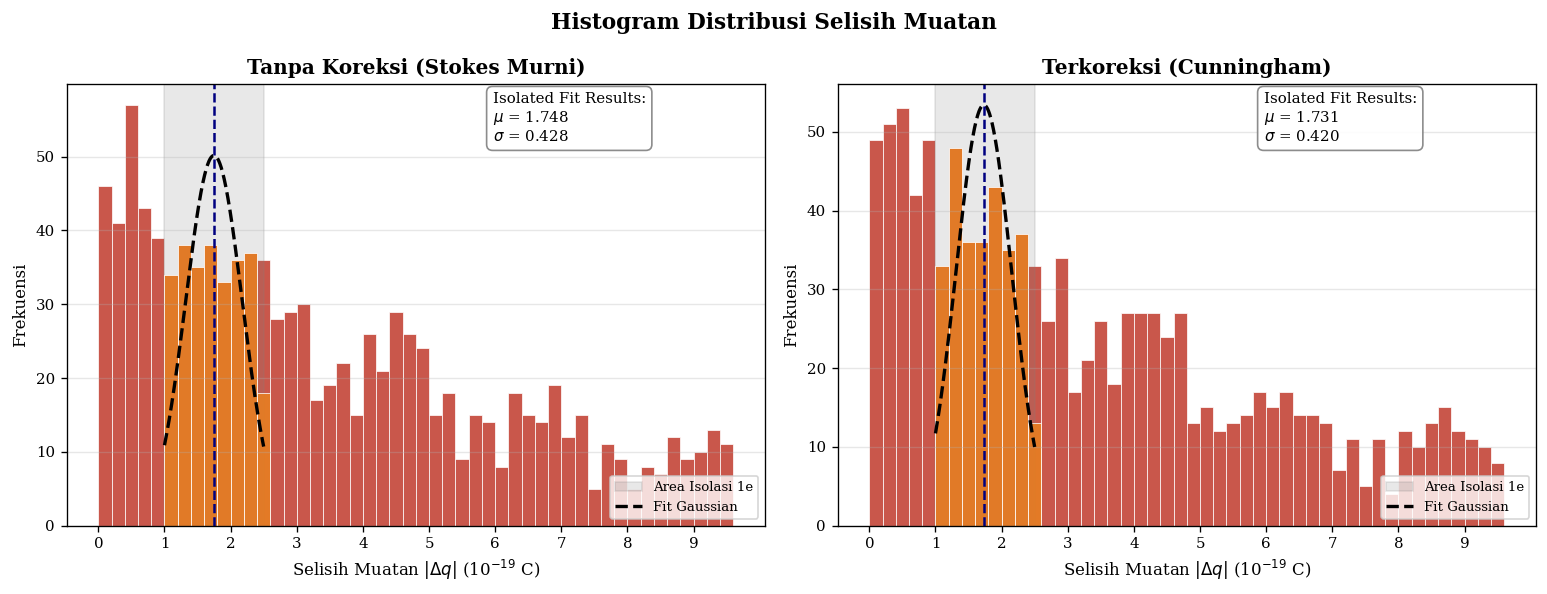

In [43]:
bins_edges = np.arange(0, 9.80, 0.20)   # bins lebih rapat
bin_width  = bins_edges[1] - bins_edges[0]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

plot_sets = [
    (diffs_nc, peak_nc, mu_nc, sig_nc, 'Tanpa Koreksi (Stokes Murni)',  axes[0]),
    (diffs_cc, peak_cc, mu_cc, sig_cc, 'Terkoreksi (Cunningham)',        axes[1]),
]

for diffs, peak_data, mu, sig, title, ax in plot_sets:
    ax.hist(diffs, bins=bins_edges, color='#c0392b',
            edgecolor='white', linewidth=0.5, alpha=0.85)

    ax.axvspan(x_lo, x_hi, color='gray', alpha=0.18,
               label='Area Isolasi 1e')

    ax.hist(peak_data, bins=bins_edges, color='#e67e22',
            edgecolor='white', linewidth=0.5, alpha=0.90)

    x_fit = np.linspace(x_lo, x_hi, 300)
    y_fit = (1/(sig*np.sqrt(2*np.pi))) * np.exp(-0.5*((x_fit-mu)/sig)**2) \
            * len(peak_data) * bin_width
    ax.plot(x_fit, y_fit, 'k--', linewidth=2.0, label='Fit Gaussian')

    ax.axvline(mu, color='navy', linestyle='--', linewidth=1.5)

    ax.text(0.61, 0.87,
            f'Isolated Fit Results:\n$\\mu$ = {mu:.3f}\n$\\sigma$ = {sig:.3f}',
            transform=ax.transAxes, fontsize=9,
            bbox=dict(boxstyle='round,pad=0.4', fc='white', ec='gray', alpha=0.9))

    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel(r'Selisih Muatan $|\Delta q|$ (10$^{-19}$ C)', fontsize=10)
    ax.set_ylabel('Frekuensi', fontsize=10)
    ax.set_xticks(np.arange(0, 10, 1))   # <-- fix sumbu-x: 0,1,2,...,9
    ax.legend(fontsize=8, loc='lower right')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Histogram Distribusi Selisih Muatan',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


# Tabel. Hasil Perhitungan Muatan dan Bilangan Kuantisasi (n) (Tanpa & koreksi Cunningham)

In [36]:
e_hist_nc = mu_nc * 1e-19
e_hist_cc = mu_cc * 1e-19

n_nc    = np.round(qavg_nc / e_hist_nc).astype(int)
eest_nc = qavg_nc / n_nc

n_cc    = np.round(qavg_cc / e_hist_cc).astype(int)
eest_cc = qavg_cc / n_cc

print('Tabel 4. Hasil Perhitungan Muatan dan Bilangan Kuantisasi (n) Tanpa Koreksi (×10⁻¹⁹ C):')
t6 = pd.DataFrame({'No':No,'qr':qr_nc*scale,'qf':qf_nc*scale,
                   'qavg':qavg_nc*scale,'n':n_nc,'eest':eest_nc*scale}).set_index('No')
display(t6.round(3))

print('\nTabel 5. Hasil Perhitungan Muatan dan Bilangan Kuantisasi (n) Metode Cunningham (×10⁻¹⁹ C):')
t7 = pd.DataFrame({'No':No,'qr':qr_cc*scale,'qf':qf_cc*scale,
                   'qavg':qavg_cc*scale,'n':n_cc,'eest':eest_cc*scale}).set_index('No')
display(t7.round(3))

Tabel 4. Hasil Perhitungan Muatan dan Bilangan Kuantisasi (n) Tanpa Koreksi (×10⁻¹⁹ C):


,qr,qf,qavg,n,eest
No,,,,,
1,11.229,15.448,13.338,8,1.667
2,6.324,4.547,5.435,3,1.812
3,17.366,26.754,22.060,13,1.697
4,10.474,10.070,10.272,6,1.712
5,6.368,17.311,11.839,7,1.691
6,6.845,6.083,6.464,4,1.616
7,6.048,7.949,6.999,4,1.750
8,6.760,4.990,5.875,3,1.958
9,5.466,5.147,5.307,3,1.769



Tabel 5. Hasil Perhitungan Muatan dan Bilangan Kuantisasi (n) Metode Cunningham (×10⁻¹⁹ C):


,qr,qf,qavg,n,eest
No,,,,,
1,10.170,13.991,12.080,7,1.726
2,5.529,3.975,4.752,3,1.584
3,15.908,24.507,20.207,12,1.684
4,9.405,9.042,9.223,5,1.845
5,5.602,15.229,10.415,6,1.736
6,5.994,5.327,5.661,3,1.887
7,5.327,7.001,6.164,4,1.541
8,5.874,4.336,5.105,3,1.702
9,4.747,4.470,4.608,3,1.536


In [37]:
def linear_fit_origin(x, y):
    x, y   = np.array(x, float), np.array(y, float)
    m      = np.sum(x*y) / np.sum(x**2)
    y_fit  = m * x
    SS_res = np.sum((y - y_fit)**2)
    SS_tot = np.sum((y - y.mean())**2)
    R2     = 1 - SS_res / SS_tot
    s2     = SS_res / (len(x) - 1)   # df = n-1 (1 parameter)
    Sm     = np.sqrt(s2 / np.sum(x**2))
    return m, R2, Sm

m_nc, R2_nc, Sm_nc = linear_fit_origin(n_nc, qavg_nc*scale)
m_cc, R2_cc, Sm_cc = linear_fit_origin(n_cc, qavg_cc*scale)

print('Hasil Regresi Linear:')
regr_res = pd.DataFrame({
    'e_regr (slope) ×10⁻¹⁹ C' : [m_nc,  m_cc],
    'Ralat Sm ×10⁻¹⁹ C'        : [Sm_nc, Sm_cc],
    'Intercept'                 : ['0 (origin)', '0 (origin)'],
    'R²'                        : [R2_nc, R2_cc],
    'Error vs literatur (%)'    :
        [abs(m_nc-e_lit*scale)/(e_lit*scale)*100,
         abs(m_cc-e_lit*scale)/(e_lit*scale)*100],
}, index=['Tanpa Koreksi','Cunningham'])
display(regr_res.round(4))

print(f'\n  e_regr (Tanpa Koreksi) = ({m_nc:.3f} ± {Sm_nc:.3f}) ×10⁻¹⁹ C')
print(f'  e_regr (Cunningham)    = ({m_cc:.3f} ± {Sm_cc:.3f}) ×10⁻¹⁹ C')

Hasil Regresi Linear:


,e_regr (slope) ×10⁻¹⁹ C,Ralat Sm ×10⁻¹⁹ C,Intercept,R²,Error vs literatur (%)
Tanpa Koreksi,1.7383,0.0118,0 (origin),0.9856,8.5083
Cunningham,1.7235,0.0123,0 (origin),0.9851,7.5864



  e_regr (Tanpa Koreksi) = (1.738 ± 0.012) ×10⁻¹⁹ C
  e_regr (Cunningham)    = (1.724 ± 0.012) ×10⁻¹⁹ C


# Regresi Linear

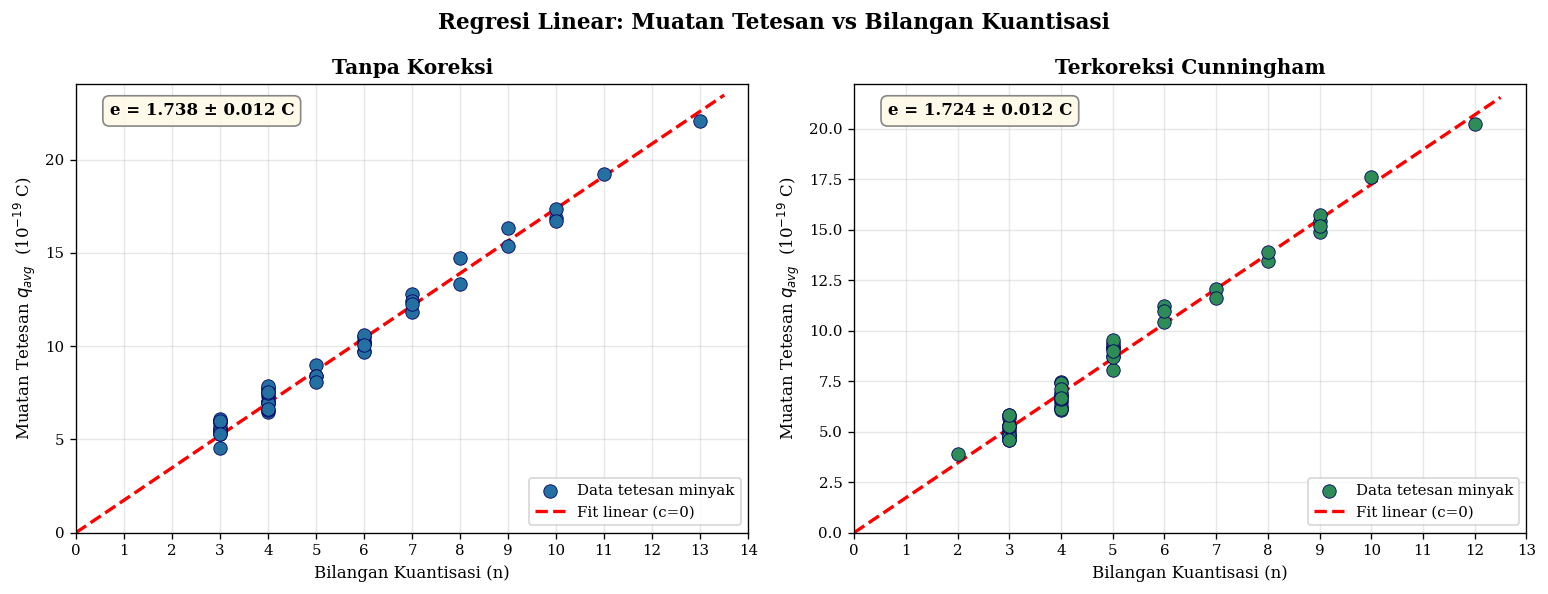

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

plot_regr = [
    (n_nc, qavg_nc*scale, m_nc, R2_nc, Sm_nc, [0.14,0.44,0.63], 'Tanpa Koreksi',       axes[0]),
    (n_cc, qavg_cc*scale, m_cc, R2_cc, Sm_cc, [0.18,0.55,0.34], 'Terkoreksi Cunningham', axes[1]),
]

for n_arr, q_arr, m, R2, Sm, col, title, ax in plot_regr:
    ax.scatter(n_arr, q_arr, s=65, color=col, edgecolors=[0,0,0.4],
               linewidths=0.5, zorder=5, label='Data tetesan minyak')

    x_line = np.array([0, max(n_arr)+0.5])
    ax.plot(x_line, m*x_line, 'r--', linewidth=2.0, label='Fit linear (c=0)')

    ax.text(0.05, 0.93,
            f'e = {m:.3f} ± {Sm:.3f} C',
            transform=ax.transAxes, fontsize=10, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.4', fc='#fef9e7', ec='gray', alpha=0.95))
    ax.text(0.05, 0.82, f'',
            transform=ax.transAxes, fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='gray', alpha=0.8))

    ax.set_xlim(0, max(n_arr)+1)
    ax.set_ylim(0, max(q_arr)+2)
    ax.set_xlabel('Bilangan Kuantisasi (n)', fontsize=10)
    ax.set_ylabel(r'Muatan Tetesan $q_{avg}$  (10$^{-19}$ C)', fontsize=10)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xticks(range(0, int(max(n_arr))+2))
    ax.legend(fontsize=9, loc='lower right')
    ax.grid(alpha=0.3)

plt.suptitle('Regresi Linear: Muatan Tetesan vs Bilangan Kuantisasi',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [39]:
print(f'Nilai literatur: e = 1.602 × 10⁻¹⁹ C\n')

summary = pd.DataFrame([
    {'Metode':'ehist  (Tanpa Koreksi)', 'Nilai':mu_nc, 'Ralat':se_nc,
     'Error (%)': abs(mu_nc-e_lit*scale)/(e_lit*scale)*100},
    {'Metode':'eregr  (Tanpa Koreksi)', 'Nilai':m_nc,  'Ralat':Sm_nc,
     'Error (%)': abs(m_nc -e_lit*scale)/(e_lit*scale)*100},
    {'Metode':'ehist  (Cunningham)',    'Nilai':mu_cc, 'Ralat':se_cc,
     'Error (%)': abs(mu_cc-e_lit*scale)/(e_lit*scale)*100},
    {'Metode':'eregr  (Cunningham)',    'Nilai':m_cc,  'Ralat':Sm_cc,
     'Error (%)': abs(m_cc -e_lit*scale)/(e_lit*scale)*100},
]).set_index('Metode')
summary['Hasil ×10⁻¹⁹ C'] = summary.apply(
    lambda r: f"({r['Nilai']:.3f} ± {r['Ralat']:.3f})", axis=1)
display(summary[['Hasil ×10⁻¹⁹ C','Error (%)']].round(2))

Nilai literatur: e = 1.602 × 10⁻¹⁹ C



,Hasil ×10⁻¹⁹ C,Error (%)
Metode,,
ehist (Tanpa Koreksi),(1.748 ± 0.026),9.11
eregr (Tanpa Koreksi),(1.738 ± 0.012),8.51
ehist (Cunningham),(1.731 ± 0.025),8.07
eregr (Cunningham),(1.724 ± 0.012),7.59


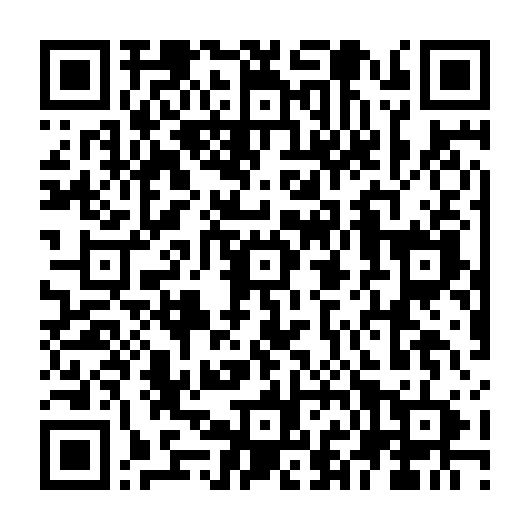

In [40]:
!pip install qrcode[pil]  # Install library qrcode
import qrcode

colab_link = "https://colab.research.google.com/github/simsim-px/Praktikum-Fisika/blob/main/UAP_Milikan_Koreksi_Cunnningham.ipynb"

qr = qrcode.make(colab_link)
qr.save("colab_qr.png")

from IPython.display import display
display(qr)